In [1]:
import numpy as np    
import matplotlib.pyplot as plt
%matplotlib inline    

from RENDES_fizinfo import *

In [2]:
auto_raw = GPS_to_num_kinem('Gyor-Bodajk.csv', orig='first')
auto = num_kinem_smooth_r(auto_raw, 0.1, lam=50, err_report=True)
#auto.plot_rcomp()

Adatsor pontosság: RMS=5.813; MAX=11.000
Eltérés          : RMS=1.120; MAX=6.780


In [ ]:
# a) Határozza meg a teljes útra a megtett távolságot és az átlagos sebességnagyságot! (2 p)
auto.calc_pathlength()
print(f'A teljes megtett ut: {auto.pathlength[-1]:.2f} m.')

# sebesség a helyvektorból
auto.calc_r_to_v()

# a sebesség vektor nagysága
auto.v_abs = vect_abs(auto.v)

# atlagsebesseg = ut / ido
v_atlag = auto.pathlength[-1] / auto.t[-1] 

print(f'Az atlagsebesseg {v_atlag:.2f} m/s volt.')

A teljes megtett ut: 67396.77 m.
Az atlagsebesseg 16.40 m/s volt.


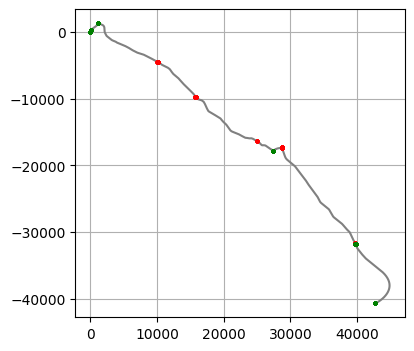

In [15]:
# b) Készítsen térképet, melyen szürkével a pálya van jelölve, 
# zölddel azok a szakaszok, ahol a sebesség 1 m/s-nál kisebb volt, 
# pirossal pedig azok, melyek esetén az autó erősen fékezett, 
# azaz tangenciális gyorsulása -0.7 m/s^2-nál kisebb volt. (5 p)

sebesseg_kisebb_kuszob = 1   # 1 m/s, sebesseg
eros_fekezes = 0.7   # m/s^2, erős fekezes küszöbe

kisebb_sebesseg_maszk = auto.v_abs < sebesseg_kisebb_kuszob   # bool maszk: kisebb sebesseg
eros_fekezes_maszk = -auto.a_t_abs > eros_fekezes   # bool maszk: erős fékezés (a_t negatív fékezésnél)

fig=plt.figure(figsize=(14,4))  
ax1=plt.subplot(111)

ax1.plot(auto.r[:,0], auto.r[:,1], color="grey")  # a pályagörbe
ax1.scatter(auto.r[eros_fekezes_maszk, 0], auto.r[eros_fekezes_maszk, 1],
            color='red',  s=4, zorder=3)                     # erős fékezési szakaszok
ax1.scatter(auto.r[kisebb_sebesseg_maszk,  0], auto.r[kisebb_sebesseg_maszk,  1],
            color='green', s=4, zorder=3)                     # kisebb sebesseg szakaszok


ax1.set_aspect(aspect='equal')
ax1.grid()

In [17]:
# c) Mennyi volt a menetidő és mennyi lett volna, ha az autó sehol sem ment volna 5 m/s-nál lassabban?

dt = auto.t[1:] - auto.t[:-1] # lépésközök időben
v_eredeti = auto.v_abs[:-1] # eredeti pillanatnyi sebességek

# korrigáljuk a sebességet: np.maximum kiválasztja a nagyobbat az eredeti és a 5 m/s közül
v_korrigalt = np.maximum(v_eredeti, 5)

# korrigáljuk az időt: új idő = régi idő * (régi sebesség / új sebesség)
# Ahol gyorsítottunk, a tört 1-nél kisebb (az idő csökken). Ahol nem, ott a tört 1 (az idő marad).
dt_korrigalt = dt * v_eredeti / v_korrigalt

print(f"Az eredeti menetidő {dt.sum():.2f} s volt.")
print(f"A hipotetikus menetidő {dt_korrigalt.sum():.2f} s lett volna.")

Az eredeti menetidő 4108.90 s volt.
A hipotetikus menetidő 3842.88 s lett volna.
